In [1]:
# 1. Import all libraries
import pandas as pd
import numpy as np


In [2]:
# 2. Load Unified Schema
folder = r"C:\Users\TANU\Documents\EDA"

unified = pd.read_csv(folder + "\\Unified_Schema.csv")

print("Unified Schema Loaded!")
print(unified.shape)
unified.head()


Unified Schema Loaded!
(42659, 32)


,sale_id,customer_id,model_id,shop_id,sale_date,quantity,discount,final_price,payment_mode,status,...,model_name_y,ram_gb_y,storage_gb_y,base_price_y,shop_location,discount_percent,start_date,end_date,campaign_name,available_units
0,SALE4000,CUST2083,MOD2111,SHOP3068,2024-11-26,1,1.05,22316.1935,Credit Card,Delivered,...,Series6,4,64,22553.0,Pune,NaN,NaN,NaN,NaN,NaN
1,SALE4001,CUST2384,MOD2021,SHOP3063,2021-07-13,1,10.48,26218.6176,Cash,Pending,...,Series16,4,256,29288.0,Pune,NaN,NaN,NaN,NaN,NaN
2,SALE4002,CUST6189,MOD2008,SHOP3004,2025-05-04,2,13.55,36469.7970,Cash,Cancelled,...,Series19,6,128,21093.0,Delhi,NaN,NaN,NaN,NaN,13.0
3,SALE4003,CUST4992,MOD2105,SHOP3041,2023-02-28,1,7.57,37230.8040,Credit Card,Pending,...,Series2,12,64,40280.0,Kolkata,NaN,NaN,NaN,NaN,8.0
4,SALE4004,CUST4707,MOD2109,SHOP3024,2020-04-12,1,18.79,35201.2866,UPI,Delivered,...,Series8,6,64,43346.0,Pune,NaN,NaN,NaN,NaN,24.0


In [3]:
# 3. Quick Data Overview
print("\nColumns:")
print(unified.columns)

print("\nInfo():")
print(unified.info())

print("\nMissing values:")
print(unified.isnull().sum())



Columns:
Index(['sale_id', 'customer_id', 'model_id', 'shop_id', 'sale_date',
       'quantity', 'discount', 'final_price', 'payment_mode', 'status',
       'brand_x', 'model_name_x', 'ram_gb_x', 'storage_gb_x', 'base_price_x',
       'offer_id', 'full_name', 'email', 'phone', 'city', 'loyalty_points',
       'brand_y', 'model_name_y', 'ram_gb_y', 'storage_gb_y', 'base_price_y',
       'shop_location', 'discount_percent', 'start_date', 'end_date',
       'campaign_name', 'available_units'],
      dtype='object')

Info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42659 entries, 0 to 42658
Data columns (total 32 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sale_id           42659 non-null  object 
 1   customer_id       42659 non-null  object 
 2   model_id          42659 non-null  object 
 3   shop_id           42659 non-null  object 
 4   sale_date         42659 non-null  object 
 5   quantity          42659 non-n

In [6]:
# DERIVED FIELDS (FIXED VERSION)

import numpy as np

# FIX: Identify correct base price column
if "base_price" in unified.columns:
    base_price_col = "base_price"
elif "base_price_x" in unified.columns:
    base_price_col = "base_price_x"
elif "base_price_y" in unified.columns:
    base_price_col = "base_price_y"
else:
    raise Exception("No base price column found!")

# FIX: Identify correct discount_percent column
if "discount_percent" in unified.columns:
    discount_col = "discount_percent"
elif "discount_percent_x" in unified.columns:
    discount_col = "discount_percent_x"
elif "discount_percent_y" in unified.columns:
    discount_col = "discount_percent_y"
else:
    discount_col = None   # offers missing is fine

# Convert required fields to numeric safely
numeric_cols = ["quantity", "final_price", base_price_col]

if discount_col:
    numeric_cols.append(discount_col)

for col in numeric_cols:
    unified[col] = pd.to_numeric(unified[col], errors="coerce")

# 1. Revenue
unified["revenue"] = unified["quantity"] * unified["final_price"]

# 2. Discount Value
if discount_col:
    unified["discount_value"] = unified[base_price_col] * (unified[discount_col] / 100)
else:
    unified["discount_value"] = np.nan

# 3. Stock Turnover
unified["stock_turnover"] = unified["quantity"] / unified["available_units"]
unified["stock_turnover"].replace([np.inf, -np.inf], np.nan, inplace=True)

print("Derived fields created successfully!")
unified[["revenue", "discount_value", "stock_turnover"]].head()


Derived fields created successfully!


C:\Users\TANU\AppData\Local\Temp\ipykernel_2972\78955246.py:47: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  unified["stock_turnover"].replace([np.inf, -np.inf], np.nan, inplace=True)


,revenue,discount_value,stock_turnover
0,22316.1935,NaN,NaN
1,26218.6176,NaN,NaN
2,72939.5940,NaN,0.153846
3,37230.8040,NaN,0.125000
4,35201.2866,NaN,0.041667


In [7]:
#One-Hot Encoding
#payment_mode
#brand
#campaign_name

# CELL 5 — ONE-HOT ENCODING
categorical_cols = ["payment_mode", "brand", "campaign_name"]

# Keep only columns that exist
categorical_cols = [c for c in categorical_cols if c in unified.columns]

unified_encoded = pd.get_dummies(unified, columns=categorical_cols, prefix=categorical_cols)

print("One-hot encoding completed!")
print("New columns added:")
print([col for col in unified_encoded.columns if any(cat in col for cat in categorical_cols)])


One-hot encoding completed!
New columns added:
['payment_mode_Cash', 'payment_mode_Credit Card', 'payment_mode_EMI', 'payment_mode_UPI']


In [10]:
one_hot_cols = [col for col in unified_encoded.columns if col.startswith("payment_mode_")]

unified_encoded[one_hot_cols].head(10)


,payment_mode_Cash,payment_mode_Credit Card,payment_mode_EMI,payment_mode_UPI
0,False,True,False,False
1,True,False,False,False
2,True,False,False,False
3,False,True,False,False
4,False,False,False,True
5,False,False,True,False
6,False,True,False,False
7,False,True,False,False
8,False,True,False,False
9,True,False,False,False


In [9]:
# PRICE BUCKETS (FIXED)

# Detect the correct base_price column
if "base_price" in unified_encoded.columns:
    base_price_col = "base_price"
elif "base_price_x" in unified_encoded.columns:
    base_price_col = "base_price_x"
elif "base_price_y" in unified_encoded.columns:
    base_price_col = "base_price_y"
else:
    raise Exception("No base price column found!")

# Define price bucket function
def price_bucket(price):
    if pd.isna(price):
        return "Unknown"
    if price < 10000:
        return "Budget"
    elif 10000 <= price <= 20000:
        return "Mid"
    elif 20000 < price <= 35000:
        return "Premium"
    else:
        return "Flagship"

# Apply segmentation
unified_encoded["price_segment"] = unified_encoded[base_price_col].apply(price_bucket)

print("Price bucket segmentation created!")
unified_encoded["price_segment"].value_counts()


Price bucket segmentation created!


price_segment
Premium     25141
Mid         10251
Flagship     5779
Budget       1488
Name: count, dtype: int64

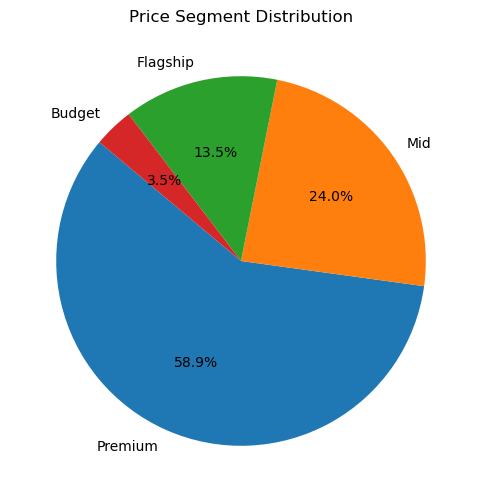

In [11]:
import matplotlib.pyplot as plt

# Count segments
price_counts = unified_encoded["price_segment"].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(price_counts, labels=price_counts.index, autopct="%1.1f%%", startangle=140)
plt.title("Price Segment Distribution")
plt.show()


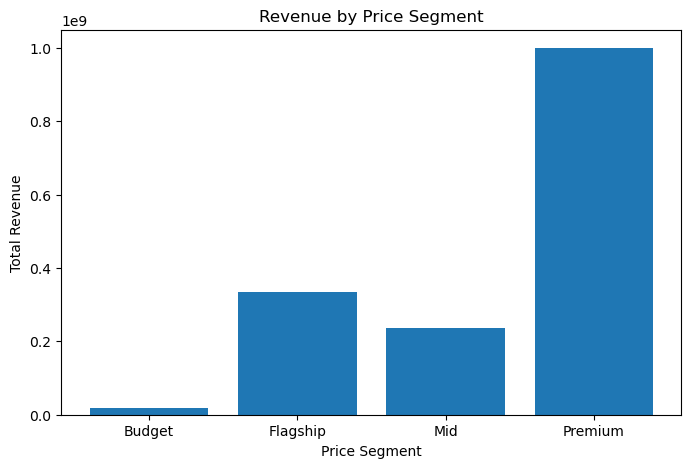

In [12]:
import matplotlib.pyplot as plt

# Group by price segment and sum revenue
revenue_by_segment = unified_encoded.groupby("price_segment")["revenue"].sum()

# Bar chart
plt.figure(figsize=(8,5))
plt.bar(revenue_by_segment.index, revenue_by_segment.values)
plt.xlabel("Price Segment")
plt.ylabel("Total Revenue")
plt.title("Revenue by Price Segment")
plt.show()


In [13]:
#Loyalty Tier Classification
#Tiers:
#Bronze → < 500
#Silver → 500–1500
#Gold → 1500–5000
#Platinum → > 5000

# LOYALTY TIERS
def loyalty_tier(points):
    if pd.isna(points):
        return "Unknown"
    if points < 500:
        return "Bronze"
    elif 500 <= points <= 1500:
        return "Silver"
    elif 1500 < points <= 5000:
        return "Gold"
    else:
        return "Platinum"

unified_encoded["loyalty_tier"] = unified_encoded["loyalty_points"].apply(loyalty_tier)

print("Loyalty tiers assigned!")
unified_encoded["loyalty_tier"].value_counts()


Loyalty tiers assigned!


loyalty_tier
Bronze    42624
Silver       35
Name: count, dtype: int64

In [ ]:
#✔ Bronze = 42,624 customers
#✔ Silver = 35 customers
#❌ Gold = 0
#❌ Platinum = 0

In [14]:
unified_encoded["loyalty_points"].describe()


count    42659.000000
mean        89.956820
std         73.325522
min          0.000000
25%         37.000000
50%         76.000000
75%        128.000000
max        620.000000
Name: loyalty_points, dtype: float64

In [15]:
#Bronze   → 0 – 37   (0–25%)
#Silver   → 38 – 76  (25–50%)
#Gold     → 77 – 128 (50–75%)
#Platinum → >128     (75–100%)

q1 = unified_encoded["loyalty_points"].quantile(0.25)
q2 = unified_encoded["loyalty_points"].quantile(0.50)
q3 = unified_encoded["loyalty_points"].quantile(0.75)

def loyalty_tier_dynamic(points):
    if points <= q1:
        return "Bronze"
    elif points <= q2:
        return "Silver"
    elif points <= q3:
        return "Gold"
    else:
        return "Platinum"

unified_encoded["loyalty_tier"] = unified_encoded["loyalty_points"].apply(loyalty_tier_dynamic)

unified_encoded["loyalty_tier"].value_counts()


loyalty_tier
Bronze      10917
Gold        10662
Platinum    10554
Silver      10526
Name: count, dtype: int64